# Seasonal Agriculture Performance Analysis

**Name** : Nilay Dawn

**Domain** : Agriculture

**Project Theme:** Seasonal Agriculture Performance

**Tools:** Pandas, Numpy, Matplotlib, Seaborn, Python


### Project Goal
The problem is to analyze the given agricultural dataset and investigate seasonal differences
in agricultural performance by identifying meaningful patterns, trends, relationships and
variations within the available data.

## 1. Problem Statement
Agricultural activities are influenced by seasonal variations in environmental conditions,
farming practices, resource availability and market conditions. As a result, agricultural
performance may differ from one season to another.

However, raw agricultural data does not clearly explain how agricultural performance changes
across seasons or what patterns can be observed in different seasonal conditions.

The problem is to analyze the given agricultural dataset and investigate seasonal differences
in agricultural performance by identifying meaningful patterns, trends, relationships and
variations within the available data.

## 2. Project Objectives
The primary objective of this project is to analyze agricultural data from different seasons
and identify meaningful patterns, trends, relationships and differences in agricultural
performance.

* Explore and understand the dataset.
* Clean and prepare the data for analysis.
* Examine how agricultural performance varies across seasons.
* Identify important seasonal patterns and trends.
* Investigate relationships between seasonal conditions and agricultural outcomes.
* Compare relevant groups within different seasons.
* Identify significant differences or unusual patterns.
* Apply appropriate statistical and visualization techniques.
* Interpret findings based on evidence from the dataset.
* Develop meaningful conclusions and data-driven recommendations.

## 3. Dataset
The dataset contains agricultural records covering different seasons, location, corps, environmental conditions, farming practices, production, cost ,revenue, profit and resource usage

**Dataset File** : seasonal_agriculture_performance_dataset.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

In [2]:
# Load the dataset
df = pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 4. Initial Data Understanding

In [4]:
print("No of rows: ", df.shape[0])
print("No of Columns: ", df.shape[1])

No of rows:  4000
No of Columns:  28


In [5]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [6]:
df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [7]:
#Random sample of records
df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,1213.70,26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [10]:
#Column names
print(df.columns.to_list())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [11]:
#Data Types and Non-null contains
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [14]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.00,3952.00,4000.00,4000.00,4000.00,4000.00,3960.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,3968.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,44714.17,526303.58,637860.05,111556.46,6045.57,5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,30266.16,294419.14,636974.71,545081.89,5572.94,8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,2594.00,26826.00,6107.00,-1019223.00,128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,21429.25,274577.50,207517.25,-148731.75,2268.75,1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,25913.00,519082.50,456830.50,3673.00,4435.00,2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,68279.00,761996.50,836874.75,216187.75,7829.75,5.15,54.90
max,15.00,1395.20,39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,1424.40,131240.00,1349990.00,5080900.00,4345421.00,40902.00,79.80,88.90


In [15]:
# categorical summary
df.describe(include=object)

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


## 5. Data Quality Analysis

In [16]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_per = (df.isnull().mean()*100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing_count":missing,
    "Missing_percentage": missing_per
})
missing_summary[missing_summary["Missing_count"]>0]

,Missing_count,Missing_percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


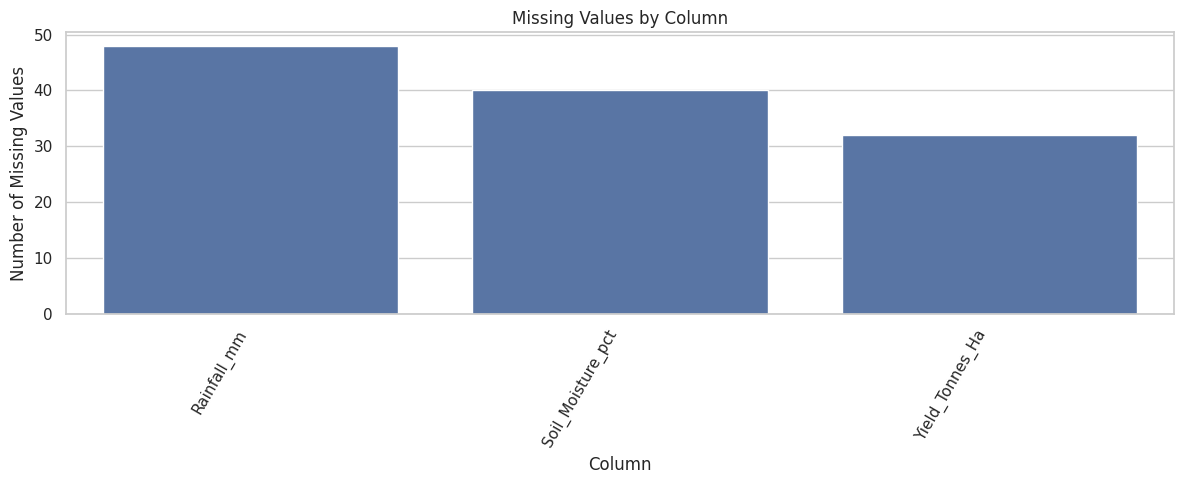

In [17]:
# Visualize missing values

plt.figure(figsize=(12, 5))
missing_plot = missing[missing > 0]
if len(missing_plot) > 0:
    sns.barplot(x=missing_plot.index, y=missing_plot.values)
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Number of Missing Values")
    plt.xlabel("Column")
    plt.title("Missing Values by Column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")




In [18]:
# Duplicate records

duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 0


In [20]:
# Check unique val for cat cols
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
  print(f"Unique values in {col}: \n")
  print(df[col].nunique(),"Unique Value \n ")
  print(df[col].dropna().unique())

Unique values in Farm_ID: 

4000 Unique Value 
 
['SF10001' 'SF10002' 'SF10003' ... 'SF13998' 'SF13999' 'SF14000']
Unique values in State: 

8 Unique Value 
 
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']
Unique values in District: 

10 Unique Value 
 
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']
Unique values in Crop: 

8 Unique Value 
 
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']
Unique values in Season: 

3 Unique Value 
 
['Kharif' 'Rabi' 'Zaid']
Unique values in Irrigation_Method: 

4 Unique Value 
 
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


### Missing Value Treatment

In [22]:
# Median imputaion for neumerical columns
neu_cols= df.select_dtypes(include=np.number).columns
for col in neu_cols:
  if df[col].isnull().sum()>0:
    df[col].fillna(df[col].median())
print("Remaining Missing values: ", df.isnull().sum().sum())

Remaining Missing values:  0


## 6. Statistical Analysis

In [25]:
stats = (df.select_dtypes(include=np.number)).describe().T
stats["range"] = stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]
stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,4000.00,7.89,4.22,0.50,4.26,7.89,11.65,15.00,14.50,7.39
Rainfall_mm,4000.00,600.92,287.19,80.00,371.58,582.00,831.98,1395.20,1315.20,460.40
Avg_Temperature_C,4000.00,26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,4000.00,63.21,11.96,25.00,54.77,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,4000.00,7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,4000.00,6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,4000.00,26.51,6.68,8.00,21.80,26.40,31.20,47.00,39.00,9.40
Nitrogen_kg_ha,4000.00,120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,4000.00,57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,4000.00,104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


In [26]:
neu_cols= df.select_dtypes(include=np.number).columns
statistical_summary = pd.DataFrame({
    "mean": df[neu_cols].mean(),
    "median": df[neu_cols].median(),
    "std": df[neu_cols].std(),
    "min": df[neu_cols].min(),
    "max": df[neu_cols].max(),
})
statistical_summary

,mean,median,std,min,max
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,1395.20
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [28]:
# Seasonal descriptive Summary
seasonal_summary = df.groupby("Season")[neu_cols].agg(["mean","median","std"])
seasonal_summary

Farm_Area_Hectares             Rainfall_mm                \
                     mean median  std        mean median    std   
Season                                                            
Kharif               7.94   8.18 4.28      849.20 853.10 183.69   
Rabi                 7.75   7.68 4.18      437.62 432.20 175.35   
Zaid                 8.09   8.09 4.16      304.65 288.20 157.24   

       Avg_Temperature_C             Humidity_pct              \
                    mean median  std         mean median  std   
Season                                                          
Kharif             28.45  28.50 2.51        71.81  71.90 8.86   
Rabi               23.49  23.50 2.46        57.89  58.10 9.00   
Zaid               31.04  31.00 2.55        52.01  52.35 9.05   

       Sunlight_Hours_Day             Soil_pH             Soil_Moisture_pct  \
                     mean median  std    mean median  std              mean   
Season                                                                        
Kharif               6.79   6.80 0.98    6.73   6.73 0.64             31.15   
Rabi                 7.59   7.60 1.00    6.67   6.67 0.64             24.07   
Zaid                 8.18   8.20 1.05    6.69   6.66 0.64             19.28   

                   Nitrogen_kg_ha              Phosphorus_kg_ha               \
       median  std           mean median   std             mean median   std   
Season                                                                         
Kharif  31.10 5.04         120.02 119.80 31.18            58.10  57.40 17.15   
Rabi    24.00 4.94         120.40 120.30 31.10            57.31  57.70 17.12   
Zaid    19.10 4.94         120.53 120.15 31.70            58.13  57.45 16.29   

       Potassium_kg_ha              Fertilizer_kg_ha               \
                  mean median   std             mean median   std   
Season                                                              
Kharif          105.30 104.80 27.03           187.08 188.20 60.82   
Rabi            103.93 104.80 28.87           185.41 185.30 59.95   
Zaid            105.42 106.30 26.66           184.64 183.95 59.47   

       Pesticide_Litre_ha             Seed_Quality_Score              \
                     mean median  std               mean median  std   
Season                                                                 
Kharif               5.08   5.18 1.96               0.82   0.82 0.10   
Rabi                 5.02   5.02 1.99               0.83   0.84 0.10   
Zaid                 5.17   5.19 1.99               0.82   0.83 0.10   

       Yield_Tonnes_Ha              Production_Tonnes                \
                  mean median   std              mean median    std   
Season                                                                
Kharif            5.63   1.94 14.39             46.31  13.24 135.70   
Rabi              5.04   1.67 12.75             41.49  11.08 121.90   
Zaid              4.64   1.46 11.27             38.89   9.97 112.00   

       Market_Price_INR_Tonne                   Total_Cost_INR            \
                         mean   median      std           mean    median   
Season                                                                     
Kharif               44850.91 25793.00 30301.56      531804.41 524840.00   
Rabi                 44747.97 26041.00 30309.56      513836.58 506733.00   
Zaid                 44212.03 25749.50 30086.23      543976.73 534833.00   

                 Revenue_INR                     Profit_INR            \
             std        mean    median       std       mean    median   
Season                                                                  
Kharif 298487.69   710719.06 520196.00 708710.37  178914.65  38808.00   
Rabi   288386.89   601526.05 438156.00 584545.52   87689.47  -3187.00   
Zaid   297576.86   519171.90 373700.50 509524.55  -24804.82 -62144.00   

                 Water_Used_m3                 Water_Efficiency_t_per_1000m3  \
      

## 7. Univariate Analysis

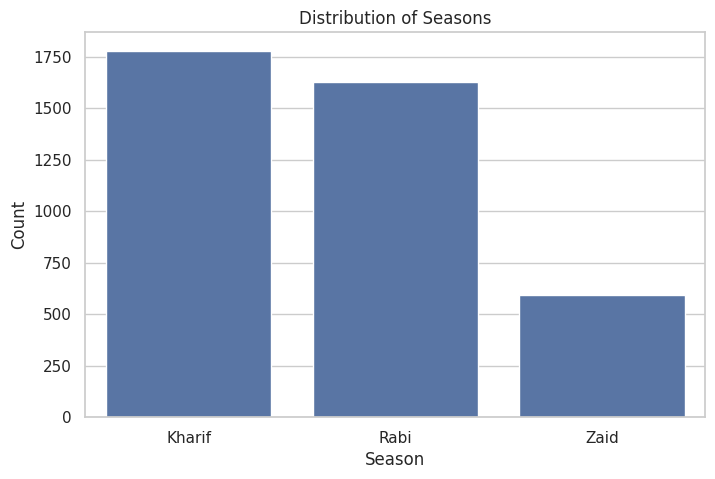

In [29]:
#Season Distribution:
season_counts = df["Season"].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(x=season_counts.index, y=season_counts.values)
plt.xlabel("Season")
plt.ylabel("Count")
plt.title("Distribution of Seasons")
plt.show()

Text(0.5, 1.0, 'Distribution of Crops')

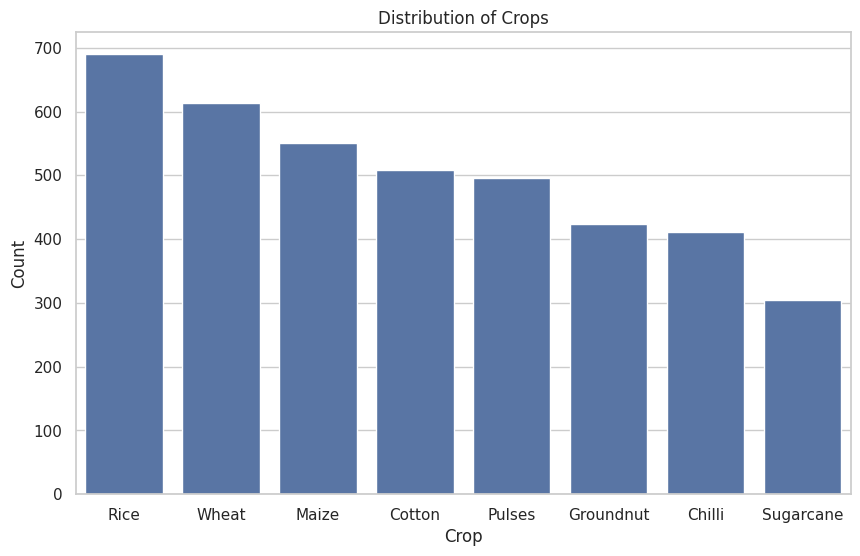

In [30]:
# Crop Distribution
crop_counts = df["Crop"].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=crop_counts.index, y=crop_counts.values)
plt.xlabel("Crop")
plt.ylabel("Count")
plt.title("Distribution of Crops")

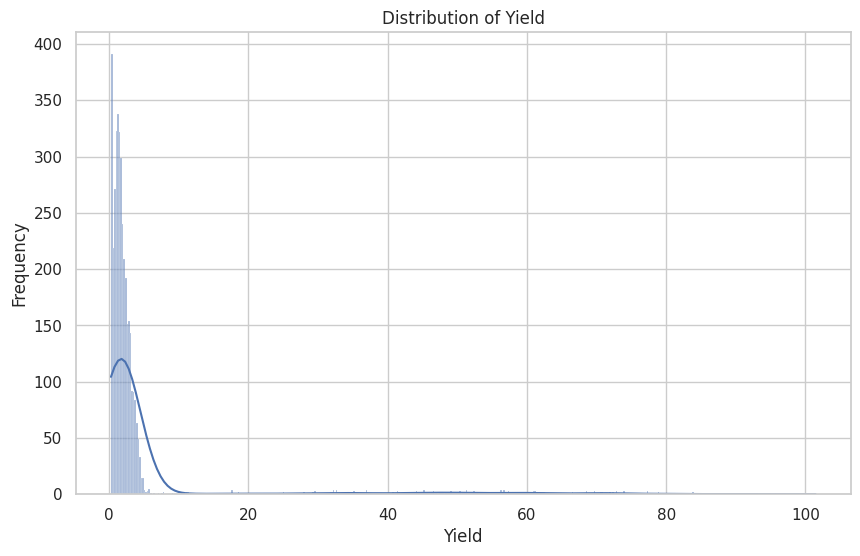

In [33]:
# Yeild Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df["Yield_Tonnes_Ha"], kde=True)
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.title("Distribution of Yield")
plt.show()

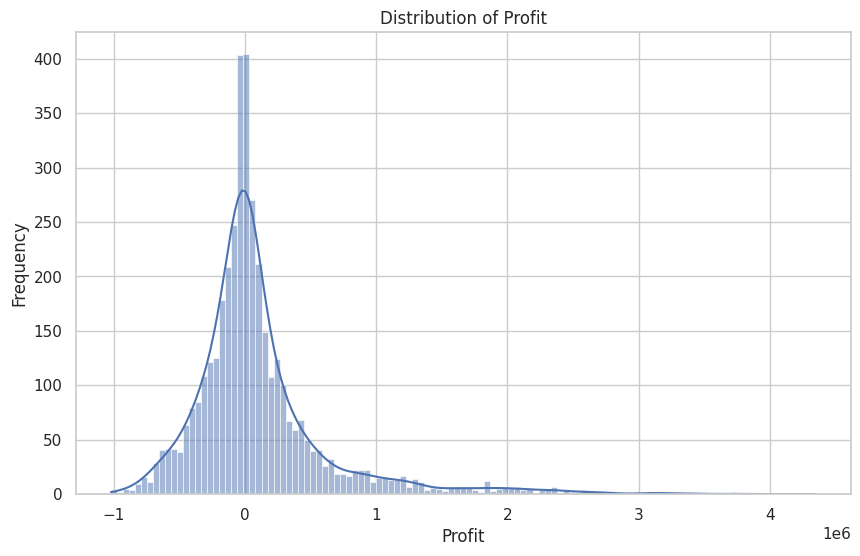

In [35]:
#Profit Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df["Profit_INR"], kde=True)
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.title("Distribution of Profit")
plt.show()

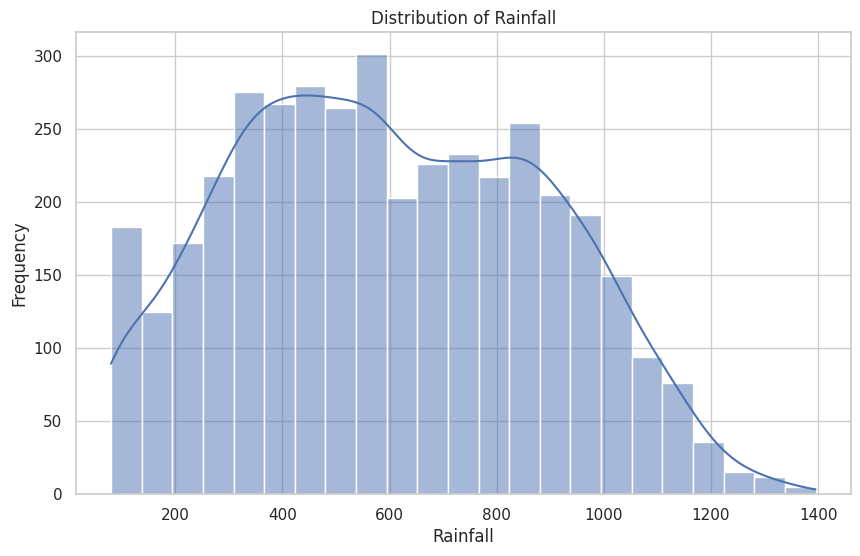

In [36]:
# Rainfall Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df["Rainfall_mm"], kde=True)
plt.xlabel("Rainfall")
plt.ylabel("Frequency")
plt.title("Distribution of Rainfall")
plt.show()

Text(0.5, 1.0, 'Box Plot of Yield by Season')

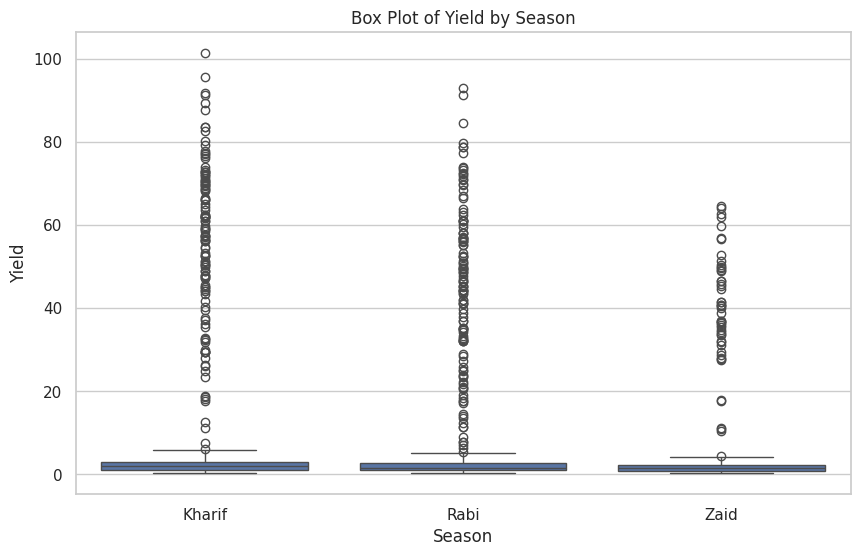

In [37]:
#Box Plot for Yeild
plt.figure(figsize=(10, 6))
sns.boxplot(x="Season", y="Yield_Tonnes_Ha", data=df)
plt.xlabel("Season")
plt.ylabel("Yield")
plt.title("Box Plot of Yield by Season")

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

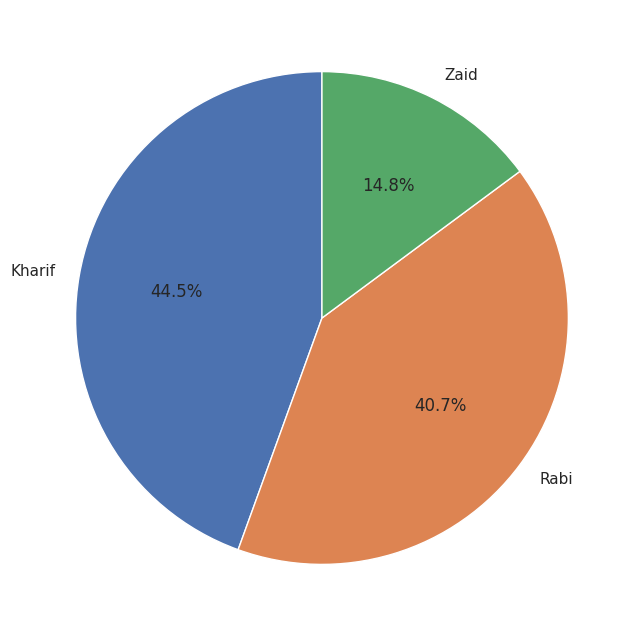

In [38]:
# Season Distribution Pie Chart
season_counts = df["Season"].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(season_counts.values, labels=season_counts.index, autopct="%1.1f%%", startangle=90)
plt

## 8. Outlier Analysis
investigate potential outliers with statistical and visual method

### Visualizing Outliers with Box Plots

Box plots are an effective way to visualize the distribution of numerical data and identify potential outliers, which appear as individual points beyond the 'whiskers' of the plot. I will create box plots for several key numerical features to inspect their distributions and identify any extreme values.

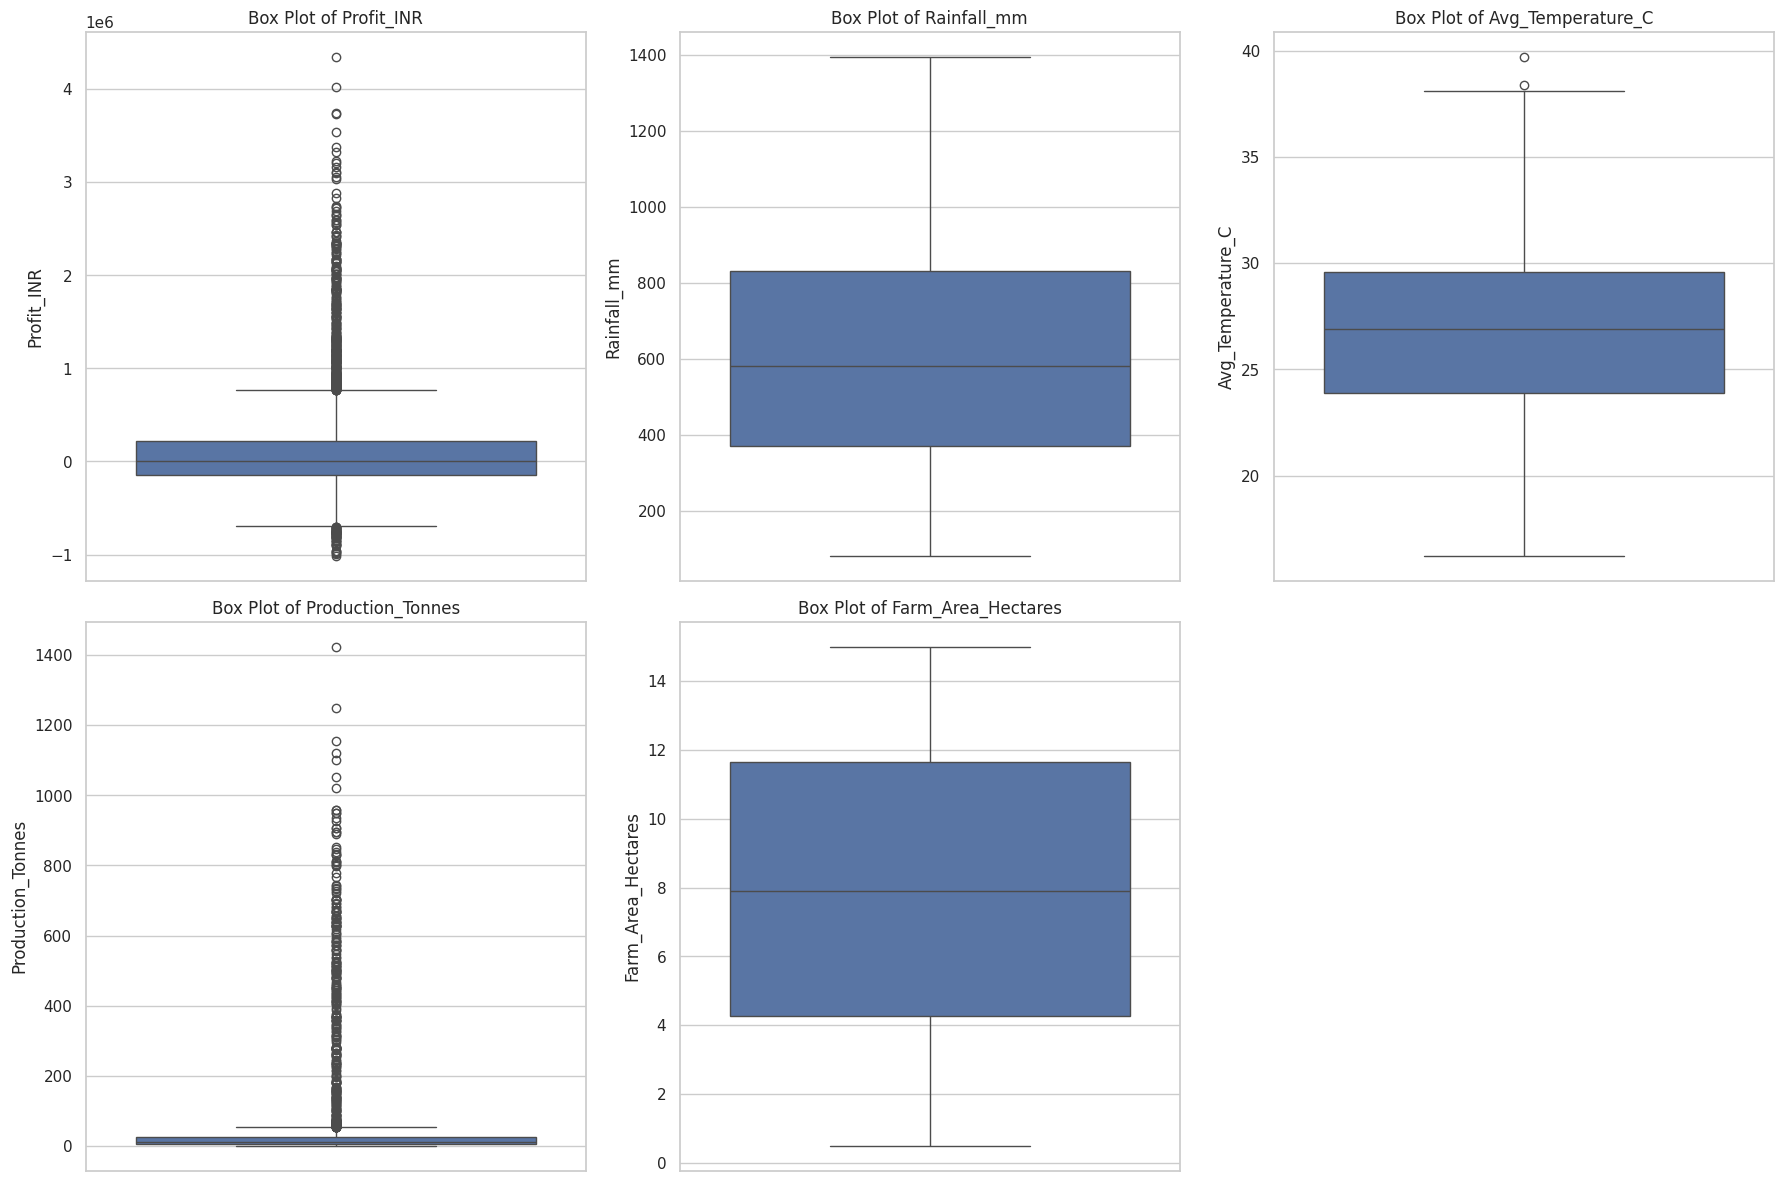

In [39]:
numerical_cols_for_outliers = ['Profit_INR', 'Rainfall_mm', 'Avg_Temperature_C', 'Production_Tonnes', 'Farm_Area_Hectares']

plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols_for_outliers):
    plt.subplot(2, 3, i + 1) # Arrange plots in 2 rows, 3 columns
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

From the box plots, it's evident that several features contain outliers. For example, 'Profit_INR', 'Rainfall_mm', 'Production_Tonnes', and 'Farm_Area_Hectares' show a number of data points extending far beyond the main distribution, indicating the presence of extreme values.

### IQR-Based Outlier Analysis


In [40]:
print('--- Outlier Counts per Numerical Column (IQR Method) ---')

outlier_counts = {}
for col in neu_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

    if len(outliers) > 0:
        print(f'{col}: {len(outliers)} outliers')
    #else:
        #print(f'{col}: No outliers detected')

# Optionally, display all outlier counts in a DataFrame
outlier_df = pd.DataFrame(outlier_counts.items(), columns=['Column', 'Outlier_Count'])
outlier_df = outlier_df.sort_values(by='Outlier_Count', ascending=False)
display(outlier_df[outlier_df['Outlier_Count'] > 0])

--- Outlier Counts per Numerical Column (IQR Method) ---
Avg_Temperature_C: 2 outliers
Humidity_pct: 6 outliers
Sunlight_Hours_Day: 26 outliers
Soil_Moisture_pct: 5 outliers
Nitrogen_kg_ha: 10 outliers
Phosphorus_kg_ha: 16 outliers
Potassium_kg_ha: 32 outliers
Fertilizer_kg_ha: 15 outliers
Pesticide_Litre_ha: 8 outliers
Yield_Tonnes_Ha: 302 outliers
Production_Tonnes: 333 outliers
Revenue_INR: 240 outliers
Profit_INR: 404 outliers
Water_Used_m3: 276 outliers
Water_Efficiency_t_per_1000m3: 322 outliers
Disease_Pest_Risk_pct: 10 outliers


,Column,Outlier_Count
18,Profit_INR,404
14,Production_Tonnes,333
20,Water_Efficiency_t_per_1000m3,322
13,Yield_Tonnes_Ha,302
19,Water_Used_m3,276
17,Revenue_INR,240
9,Potassium_kg_ha,32
4,Sunlight_Hours_Day,26
8,Phosphorus_kg_ha,16
10,Fertilizer_kg_ha,15


## 9. Bivariate Analysis

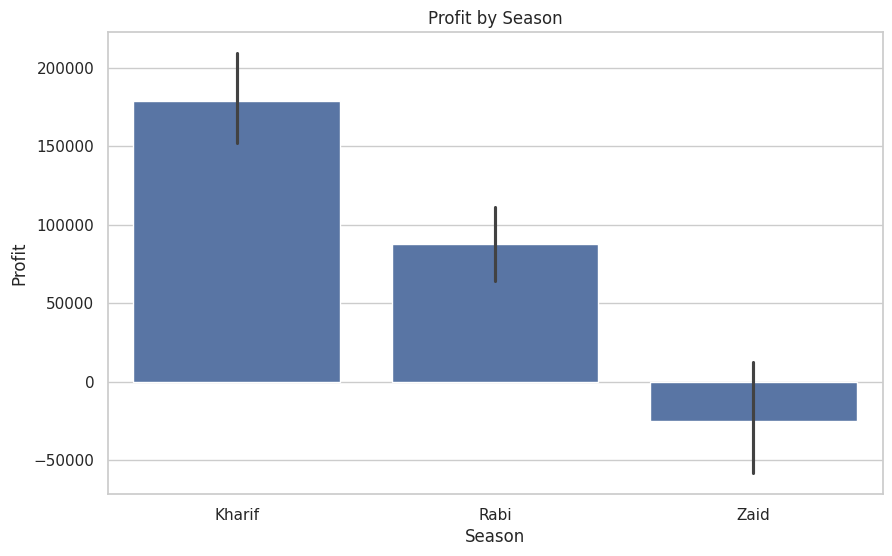

In [44]:
# Season vs Profit
plt.figure(figsize=(10, 6))
sns.barplot(x="Season", y="Profit_INR", data=df)
plt.xlabel("Season")
plt.ylabel("Profit")
plt.title("Profit by Season")
plt.show()

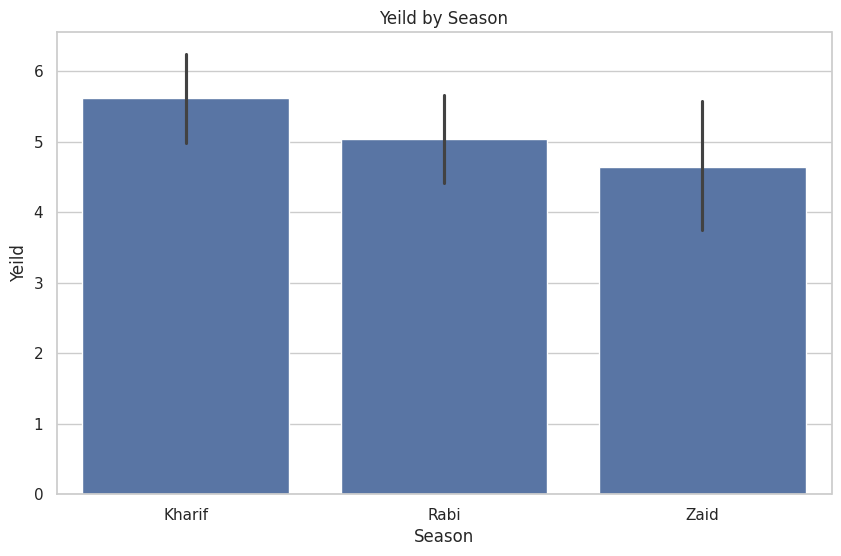

In [43]:
# Season vs Yeild
plt.figure(figsize=(10, 6))
sns.barplot(x="Season", y="Yield_Tonnes_Ha", data=df)
plt.xlabel("Season")
plt.ylabel("Yeild")
plt.title("Yeild by Season")
plt.show()

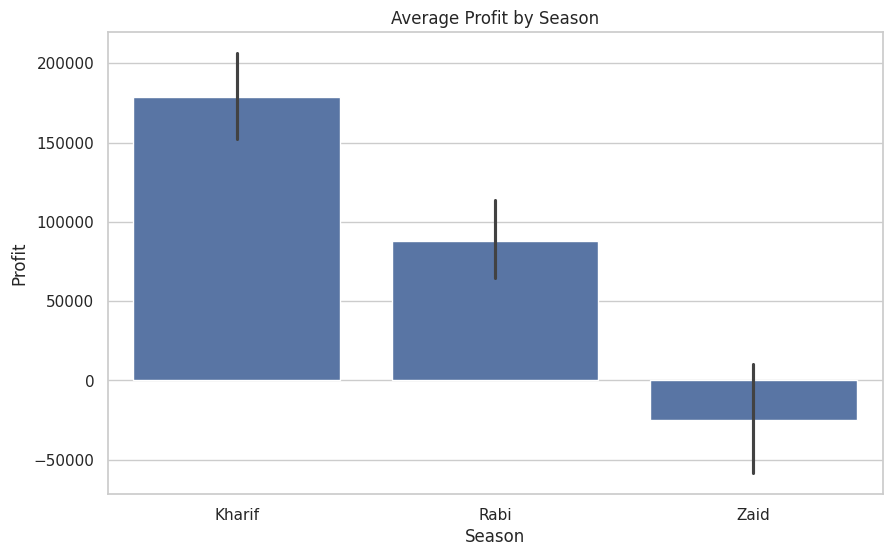

In [45]:
#Average Profit accross Season (Bar Plot)
plt.figure(figsize=(10, 6))
sns.barplot(x="Season", y="Profit_INR", data=df)
plt.xlabel("Season")
plt.ylabel("Profit")
plt.title("Average Profit by Season")
plt.show()

In [49]:
df.columns.to_list()

['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

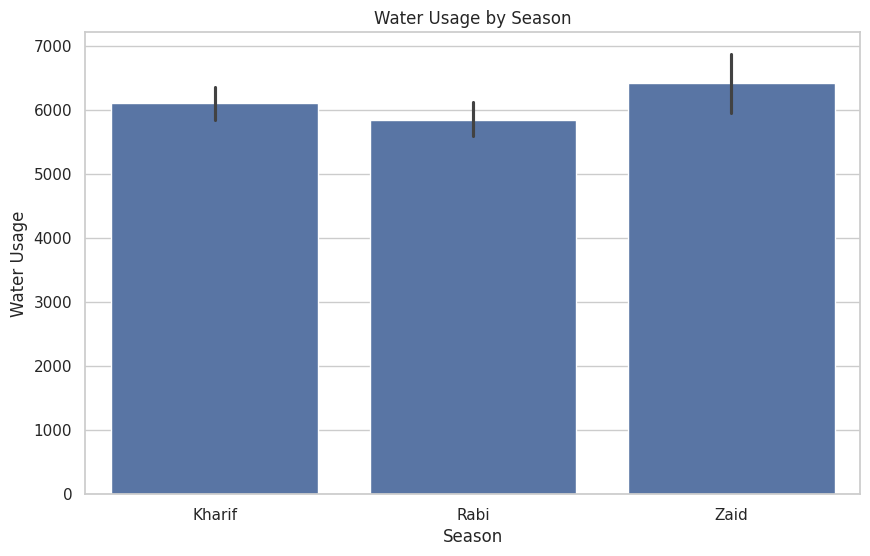

In [50]:
# Water usage across season
plt.figure(figsize=(10, 6))
sns.barplot(x="Season", y="Water_Used_m3", data=df)
plt.xlabel("Season")
plt.ylabel("Water Usage")
plt.title("Water Usage by Season")
plt.show()

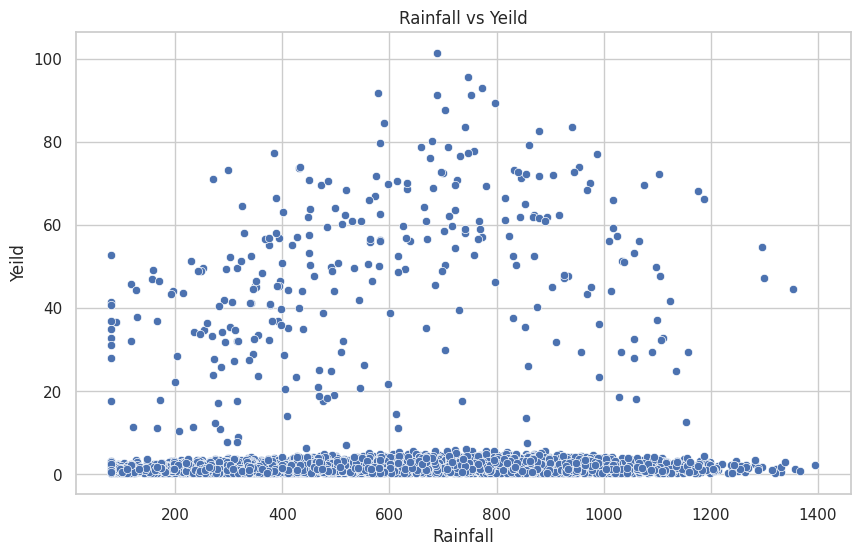

In [52]:
# Rainfall vs Yeild
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Rainfall_mm", y="Yield_Tonnes_Ha", data=df)
plt.xlabel("Rainfall")
plt.ylabel("Yeild")
plt.title("Rainfall vs Yeild")
plt.show()

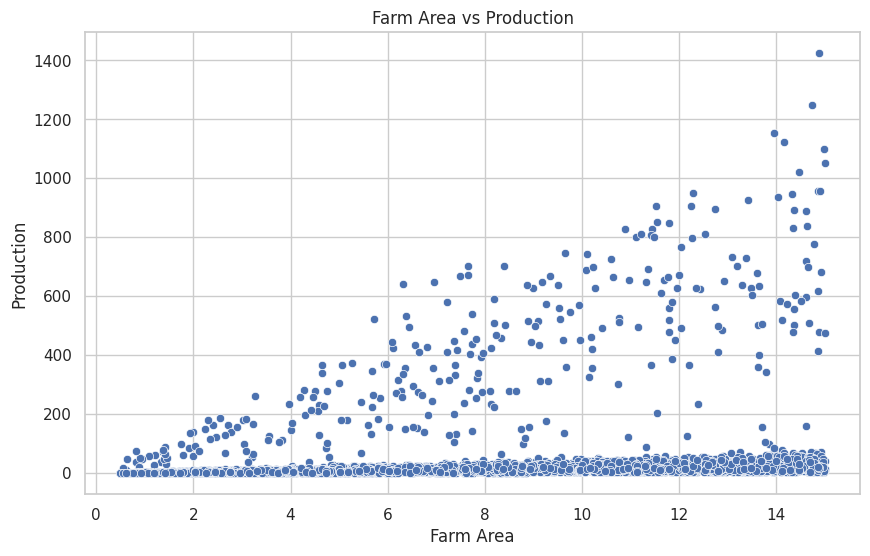

In [53]:
#Farm area vs production
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Farm_Area_Hectares", y="Production_Tonnes", data=df)
plt.xlabel("Farm Area")
plt.ylabel("Production")
plt.title("Farm Area vs Production")
plt.show()

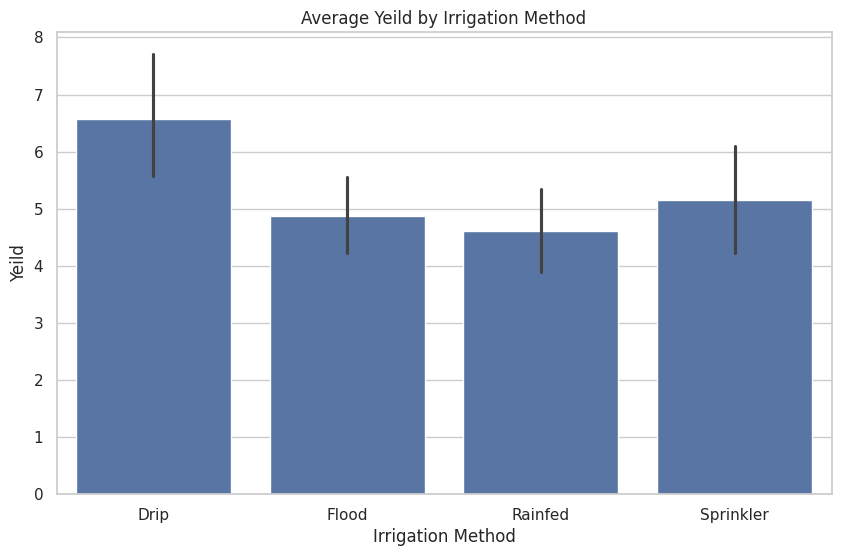

In [54]:
# Avarage Yeild accross irigation methog(Bar Plot)
plt.figure(figsize=(10, 6))
sns.barplot(x="Irrigation_Method", y="Yield_Tonnes_Ha", data=df)
plt.xlabel("Irrigation Method")
plt.ylabel("Yeild")
plt.title("Average Yeild by Irrigation Method")
plt.show()

## 10 Multivariate Analysis

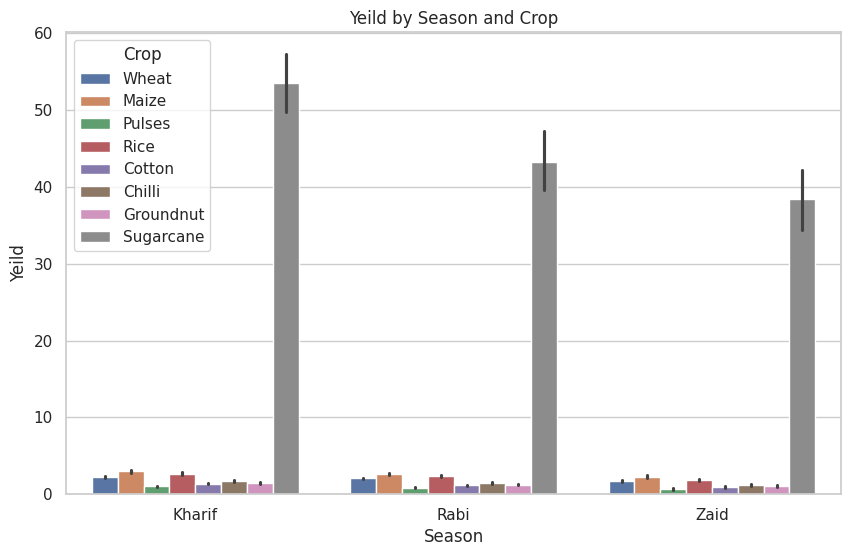

In [55]:
# Season , crop vs Yeild
plt.figure(figsize=(10, 6))
sns.barplot(x="Season", y="Yield_Tonnes_Ha", hue="Crop", data=df)
plt.xlabel("Season")
plt.ylabel("Yeild")
plt.title("Yeild by Season and Crop")
plt.show()

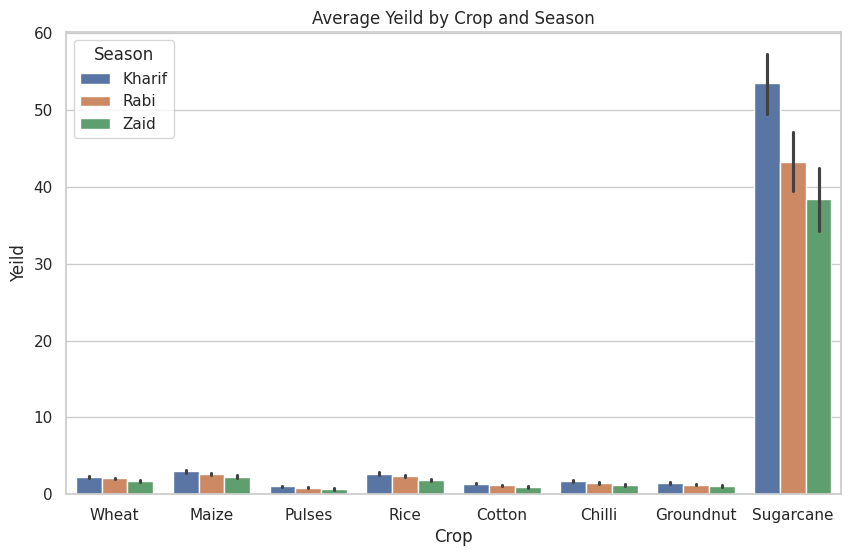

In [56]:
# Average Yeild by crop and season
plt.figure(figsize=(10, 6))
sns.barplot(x="Crop", y="Yield_Tonnes_Ha", hue="Season", data=df)
plt.xlabel("Crop")
plt.ylabel("Yeild")
plt.title("Average Yeild by Crop and Season")
plt.show()

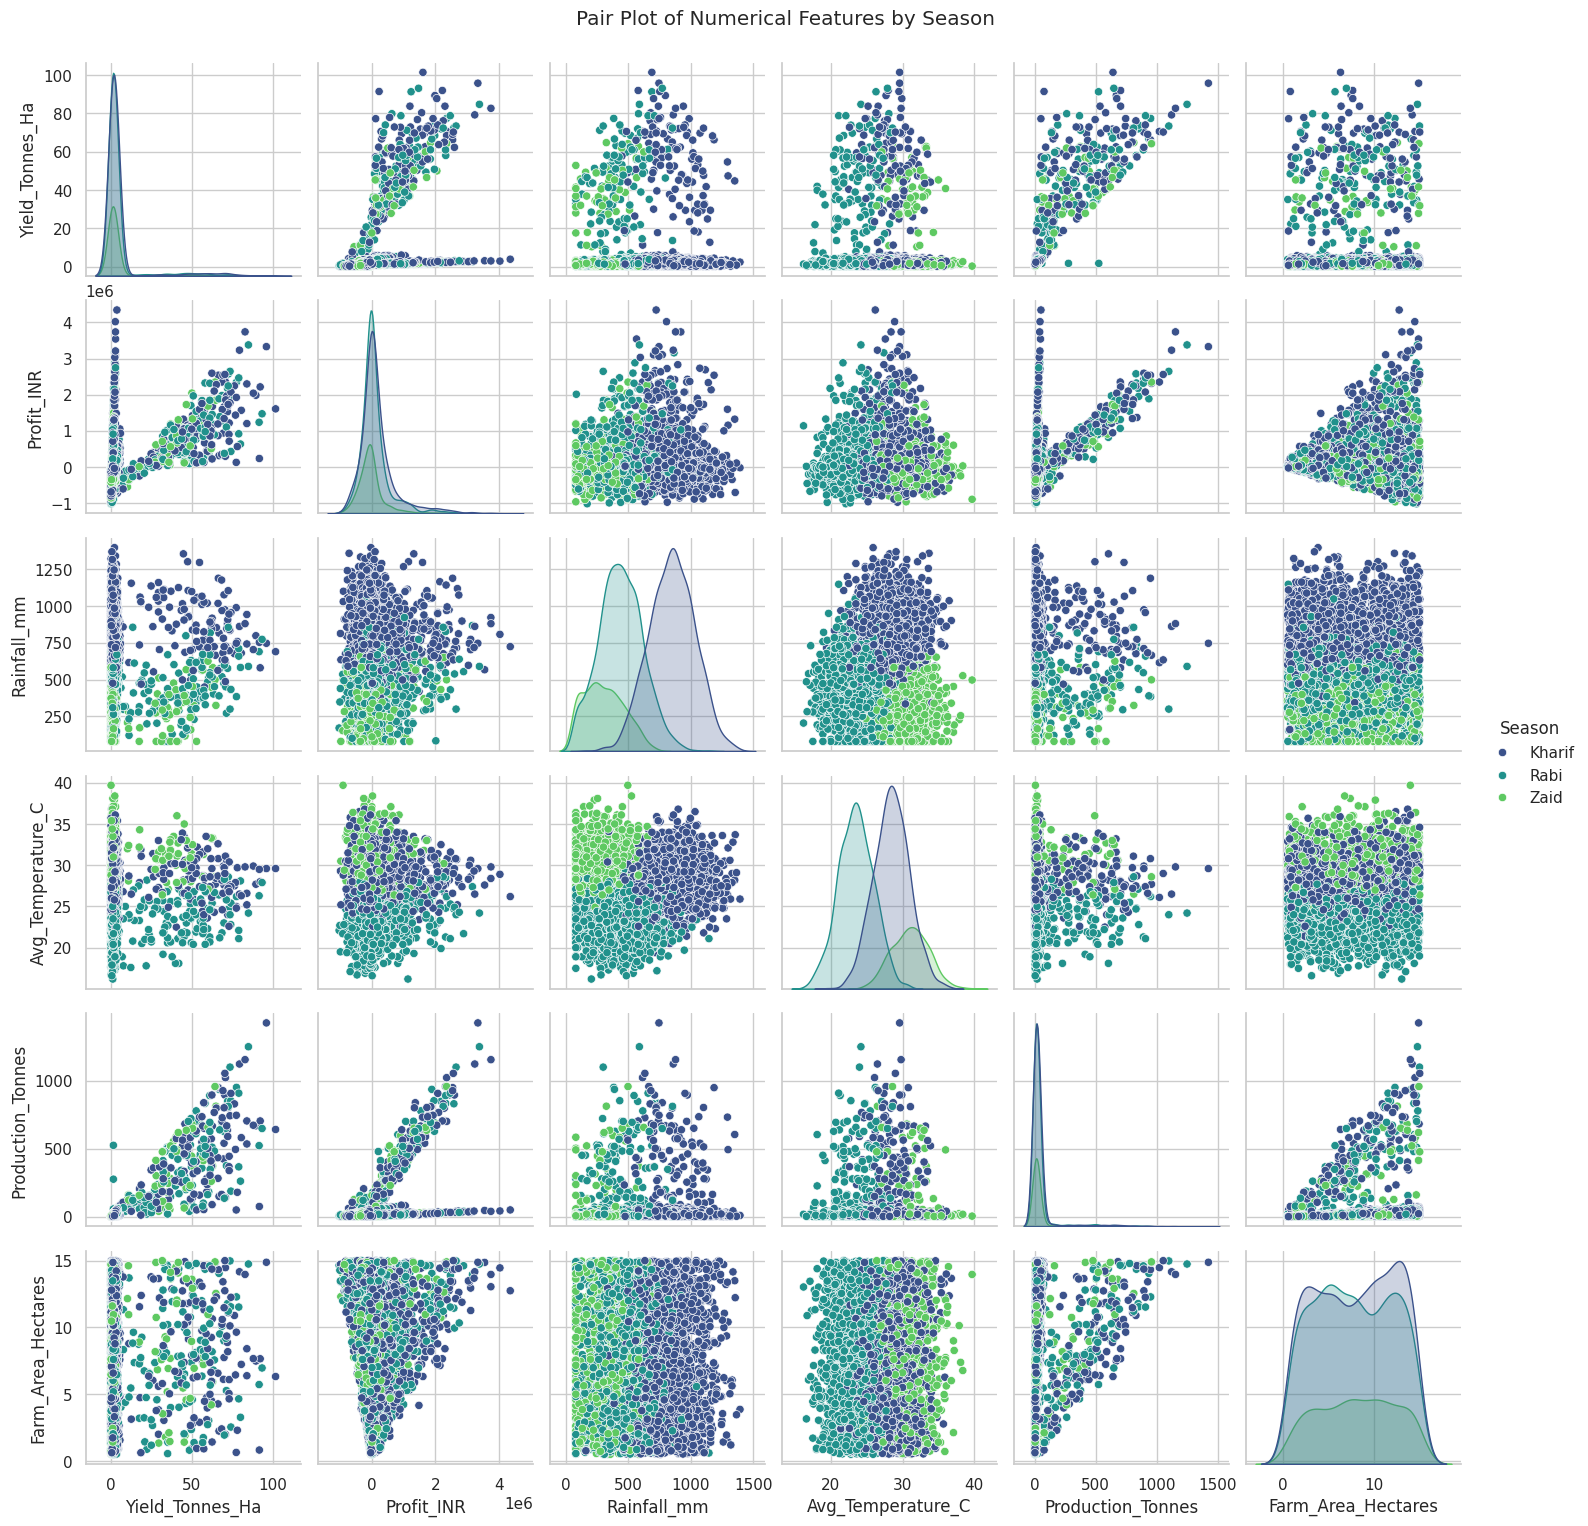

In [57]:
#Pair plot of key environmental and parformance metrics by season
numerical_cols = ['Yield_Tonnes_Ha', 'Profit_INR', 'Rainfall_mm', 'Avg_Temperature_C', 'Production_Tonnes', 'Farm_Area_Hectares']
sns.pairplot(df, hue='Season', vars=numerical_cols, palette='viridis')
plt.suptitle('Pair Plot of Numerical Features by Season', y=1.02)
plt.show()

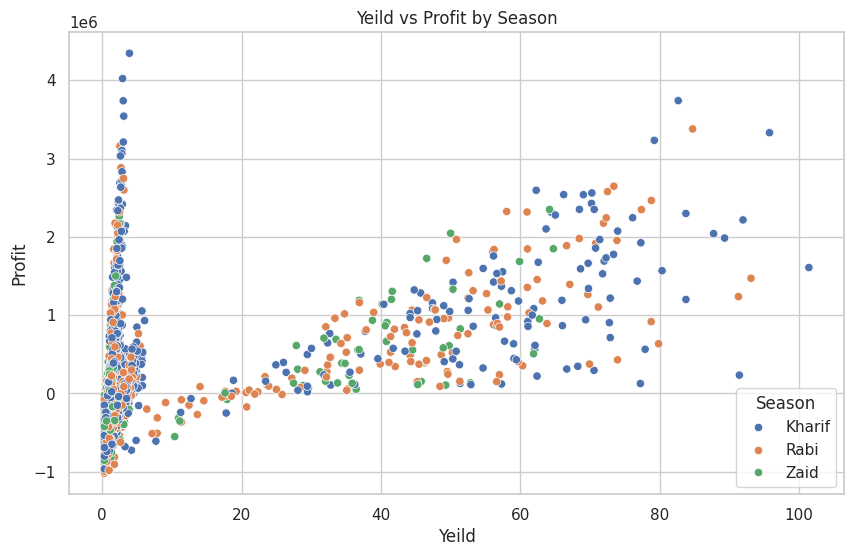

In [58]:
# yeild , profit and seasonal differences
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Yield_Tonnes_Ha", y="Profit_INR", hue="Season", data=df)
plt.xlabel("Yeild")
plt.ylabel("Profit")
plt.title("Yeild vs Profit by Season")
plt.show()

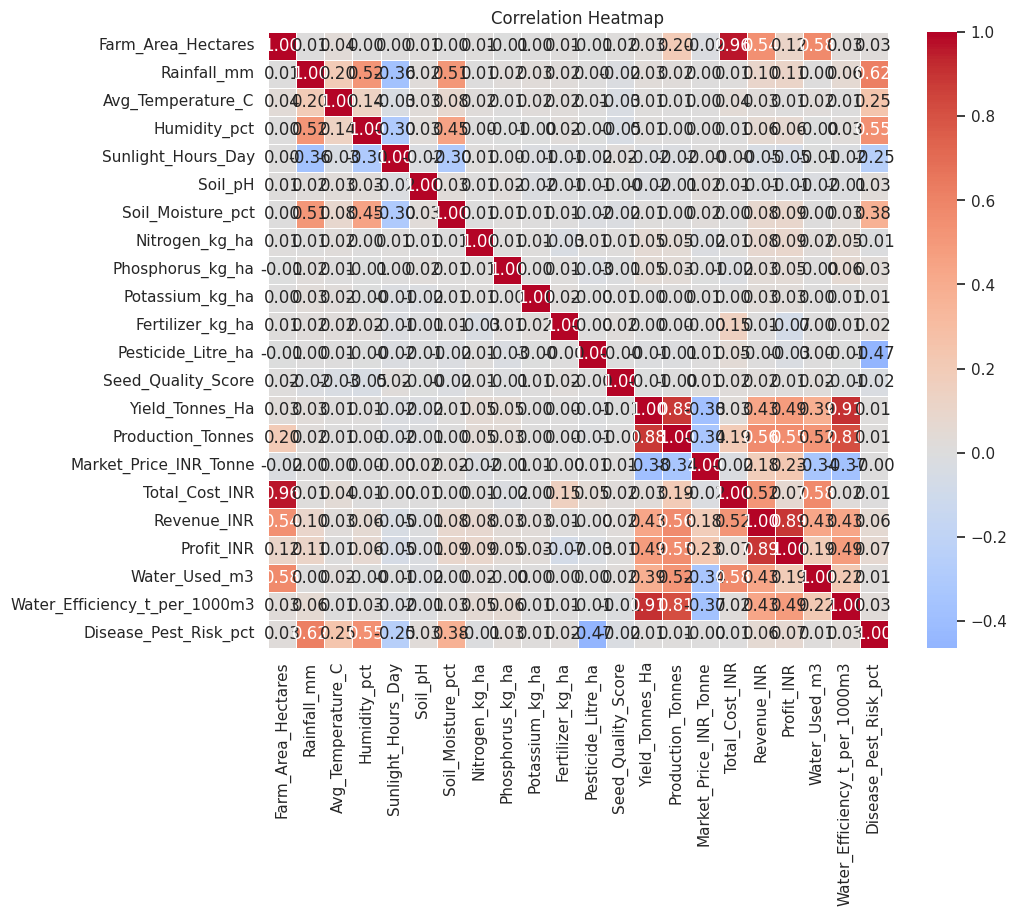

In [59]:
#correlation heatmap for neumerical variables
corr_matrix = df[neu_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f",center=0,linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## 11. Seasonal Comparison

In [60]:
#General seasonal summary
season_metrics = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used=("Water_Used_m3", "mean")
).round(2)

season_metrics


,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used
Season,,,,,,
Kharif,1779,5.63,82387.61,178914.65,318289158,6102.20
Rabi,1627,5.04,67498.88,87689.47,142670768,5846.99
Zaid,594,4.64,23098.35,-24804.82,-14734066,6419.89


In [62]:
#Crop Season summary
crop_season_metrics = df.groupby(["Crop", "Season"]).agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used=("Water_Used_m3", "mean")
)
crop_season_metrics

Average_Yield  Total_Production  Average_Profit  \
Crop      Season                                                    
Chilli    Kharif           1.73           2675.74       954380.42   
          Rabi             1.47           1787.45       638572.50   
          Zaid             1.20            638.56       448659.09   
Cotton    Kharif           1.37           2237.84       216999.55   
          Rabi             1.20           1897.64       107343.59   
          Zaid             0.96            637.62       -53925.34   
Groundnut Kharif           1.48           2024.62       108265.44   
          Rabi             1.23           1603.90        10416.54   
          Zaid             1.04            465.55       -68872.50   
Maize     Kharif           2.97           5463.54       -39332.67   
          Rabi             2.60           5030.78       -89133.40   
          Zaid             2.29           1507.08      -194049.17   
Pulses    Kharif           1.04           1831.36        43338.90   
          Rabi             0.88           1533.28       -14309.14   
          Zaid             0.67            306.46      -139227.81   
Rice      Kharif           2.70           7049.19       -64903.40   
          Rabi             2.32           4719.24       -98427.87   
          Zaid             1.90           1540.72      -227239.34   
Sugarcane Kharif          53.46          55759.37      1000790.81   
          Rabi            43.29          47118.96       731612.86   
          Zaid            38.42          16807.64       583635.80   
Wheat     Kharif           2.25           5345.95      -105871.87   
          Rabi             2.06           3807.63      -119954.57   
          Zaid             1.75           1194.72      -193208.95   

                  Total_Profit  Average_Water_Used  
Crop      Season                                    
Chilli    Kharif     176560378             4635.06  
          Rabi       104087317             4351.58  
          Zaid        28714182             4986.30  
Cotton    Kharif      46654903             5452.45  
          Rabi        21576061             5377.81  
          Zaid        -4961131             5385.88  
Groundnut Kharif      20895230             3338.39  
          Rabi         1843728             3490.11  
          Zaid        -3719115             3792.30  
Maize     Kharif      -9203845             4329.20  
          Rabi       -20768083             4416.94  
          Zaid       -16300130             4404.45  
Pulses    Kharif       9577896             2853.42  
          Rabi        -3047846             2867.45  
          Zaid        -8632124             2647.19  
Rice      Kharif     -20379669            11378.45  
          Rabi       -26969236            10178.32  
          Zaid       -23178413            11502.52  
Sugarcane Kharif     125098851            13689.51  
          Rabi        94378059            13757.14  
          Zaid        29765426            14763.53  
Wheat     Kharif     -30914586             4294.81  
          Rabi       -28429232             3804.25  
          Zaid       -16422761             3926.02

In [65]:
#Compare crop performance within each season
crop_season_summary = df.groupby(["Crop", "Season"]).agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Agerage_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).round(2).sort_values(["Season","Average_Yield"],ascending=[True,False])

crop_season_summary


,,Average_Yield,Total_Production,Average_Profit,Agerage_Water_Efficiency
Crop,Season,,,,
Sugarcane,Kharif,53.46,55759.37,1000790.81,36.00
Maize,Kharif,2.97,5463.54,-39332.67,6.05
Rice,Kharif,2.70,7049.19,-64903.40,2.17
Wheat,Kharif,2.25,5345.95,-105871.87,4.76
Chilli,Kharif,1.73,2675.74,954380.42,3.26
Groundnut,Kharif,1.48,2024.62,108265.44,3.58
Cotton,Kharif,1.37,2237.84,216999.55,2.13
Pulses,Kharif,1.04,1831.36,43338.90,3.35
Sugarcane,Rabi,43.29,47118.96,731612.86,27.92


## 12. Aditional Analysis

additional three analysis

example structure:

question

analysis

visualizaion

interpretaion

### Additional Analysis 1: Impact of Environmental Factors on Yield by Season

**Question:** How do seasonal environmental conditions (Rainfall, Average Temperature, Sunlight Hours) affect crop yield?

**Analysis:** This analysis aims to understand the relationship between key environmental variables and crop yield, differentiated by season. By visualizing these relationships, we can identify which environmental factors have a more pronounced impact on yield in specific seasons.

**Visualization:**

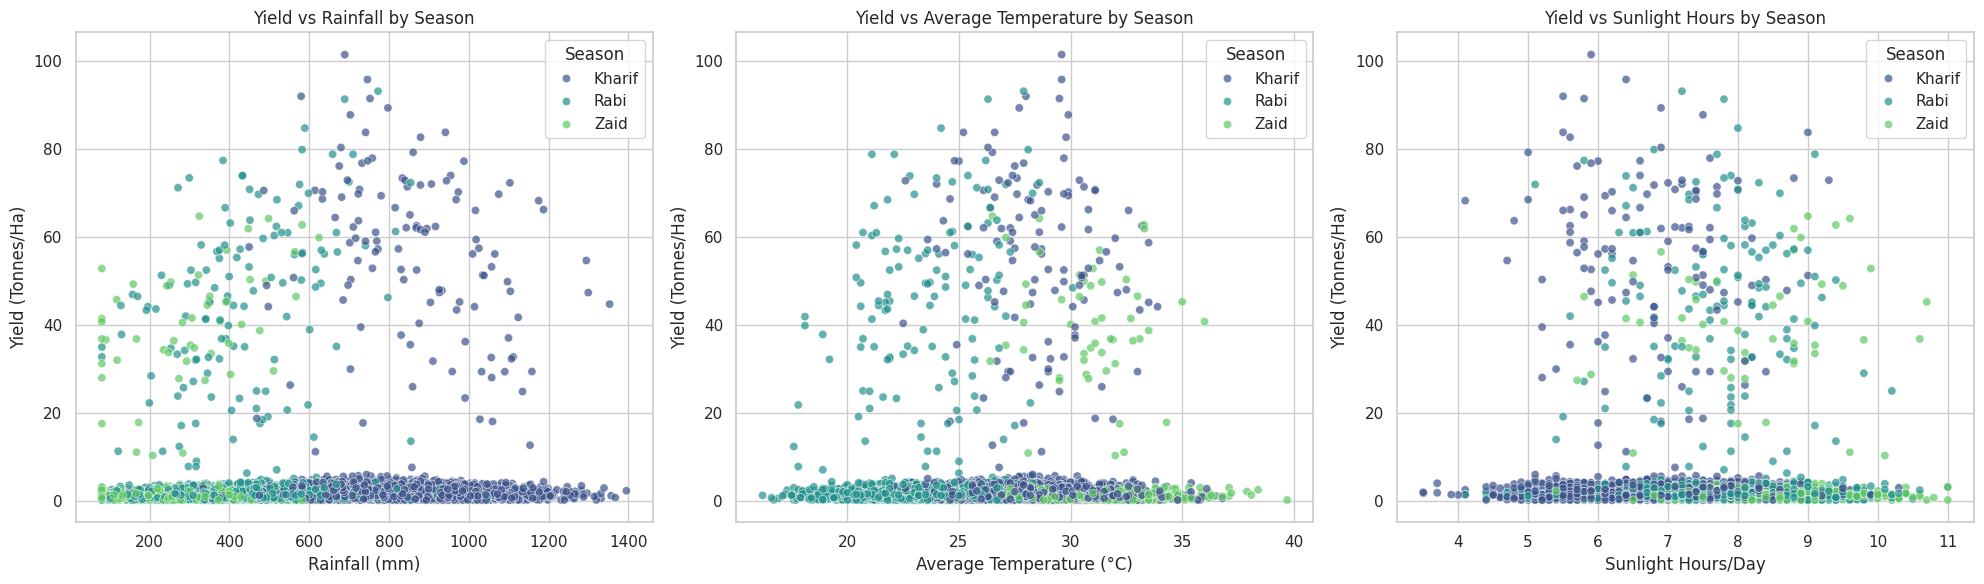

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.scatterplot(x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', data=df, ax=axes[0], palette='viridis', alpha=0.7)
axes[0].set_title('Yield vs Rainfall by Season')
axes[0].set_xlabel('Rainfall (mm)')
axes[0].set_ylabel('Yield (Tonnes/Ha)')

sns.scatterplot(x='Avg_Temperature_C', y='Yield_Tonnes_Ha', hue='Season', data=df, ax=axes[1], palette='viridis', alpha=0.7)
axes[1].set_title('Yield vs Average Temperature by Season')
axes[1].set_xlabel('Average Temperature (°C)')
axes[1].set_ylabel('Yield (Tonnes/Ha)')

sns.scatterplot(x='Sunlight_Hours_Day', y='Yield_Tonnes_Ha', hue='Season', data=df, ax=axes[2], palette='viridis', alpha=0.7)
axes[2].set_title('Yield vs Sunlight Hours by Season')
axes[2].set_xlabel('Sunlight Hours/Day')
axes[2].set_ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

**Interpretation:**
- The scatter plots show varying relationships between environmental factors and yield across seasons. For instance, high rainfall in Kharif season often correlates with higher yields, while in Zaid, excessive rainfall might be detrimental.
- Temperature ranges also show seasonal specificity; certain crops thrive at specific temperatures, which might be more prevalent in one season than another.
- Sunlight hours generally have a positive impact on yield, but the optimal range can differ significantly by season and crop type.

### Additional Analysis 2: Economic Performance (Profit) across Crops and Seasons

**Question:** Which crops are most profitable in each season, and how does profit vary by crop and season?

**Analysis:** This analysis delves into the economic viability of different crops across various seasons by examining their average profit. Understanding this can inform decisions on crop selection and seasonal planning for maximizing profitability.

**Visualization:**

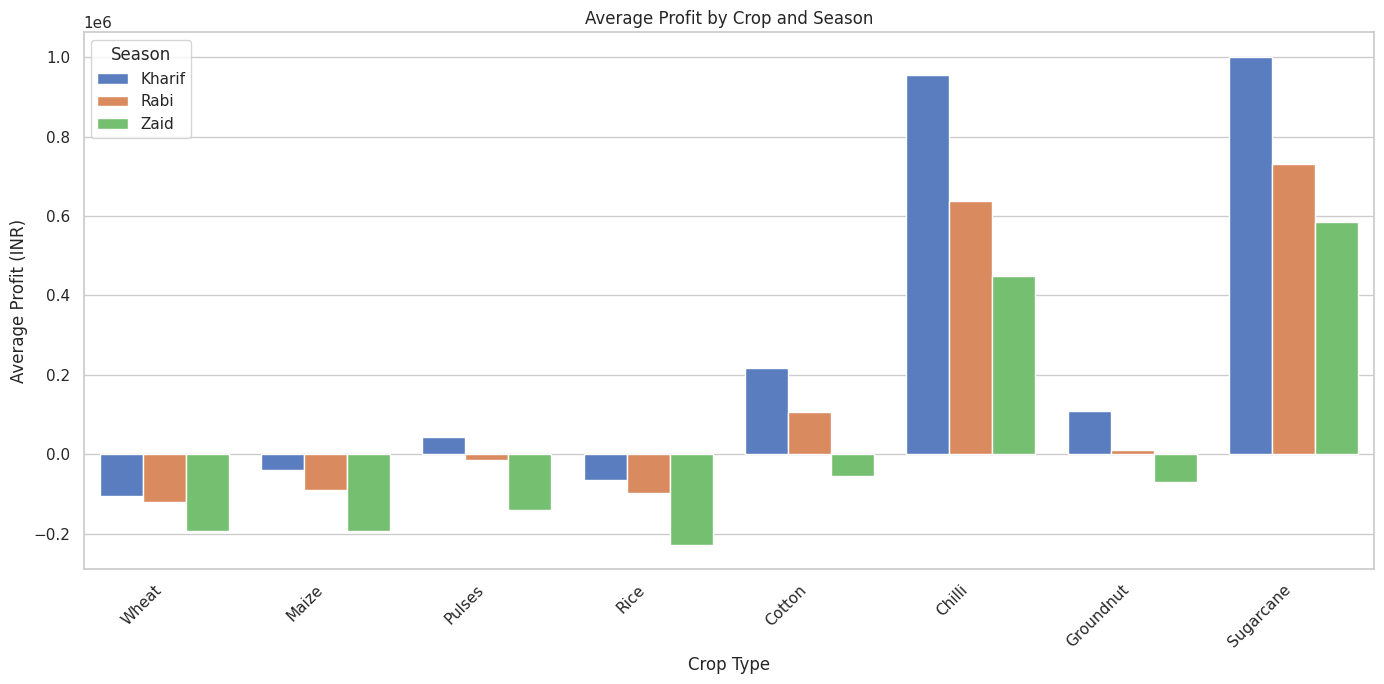

In [67]:
plt.figure(figsize=(14, 7))
sns.barplot(x='Crop', y='Profit_INR', hue='Season', data=df, palette='muted', errorbar=None)
plt.title('Average Profit by Crop and Season')
plt.xlabel('Crop Type')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Season')
plt.tight_layout()
plt.show()

**Interpretation:**
- Sugarcane consistently appears to be the most profitable crop across all seasons, with Kharif showing the highest average profit.
- Chilli also demonstrates good profitability, particularly in the Kharif and Rabi seasons.
- Conversely, some crops like Maize, Rice, and Wheat show negative average profits in certain seasons, especially Zaid, indicating higher costs or lower market prices during these periods. Pulses and Groundnut also show negative or very low profits in Zaid.
- This suggests that crop selection based on seasonal suitability is crucial for optimizing financial returns.

### Additional Analysis 3: Water Usage Efficiency by Season and Crop

**Question:** How does water usage efficiency vary across different crops and seasons?

**Analysis:** Water efficiency is a critical metric for sustainable agriculture. This analysis investigates how efficiently water is used to produce yield for different crops in each season. Higher water efficiency indicates better resource management.

**Visualization:**

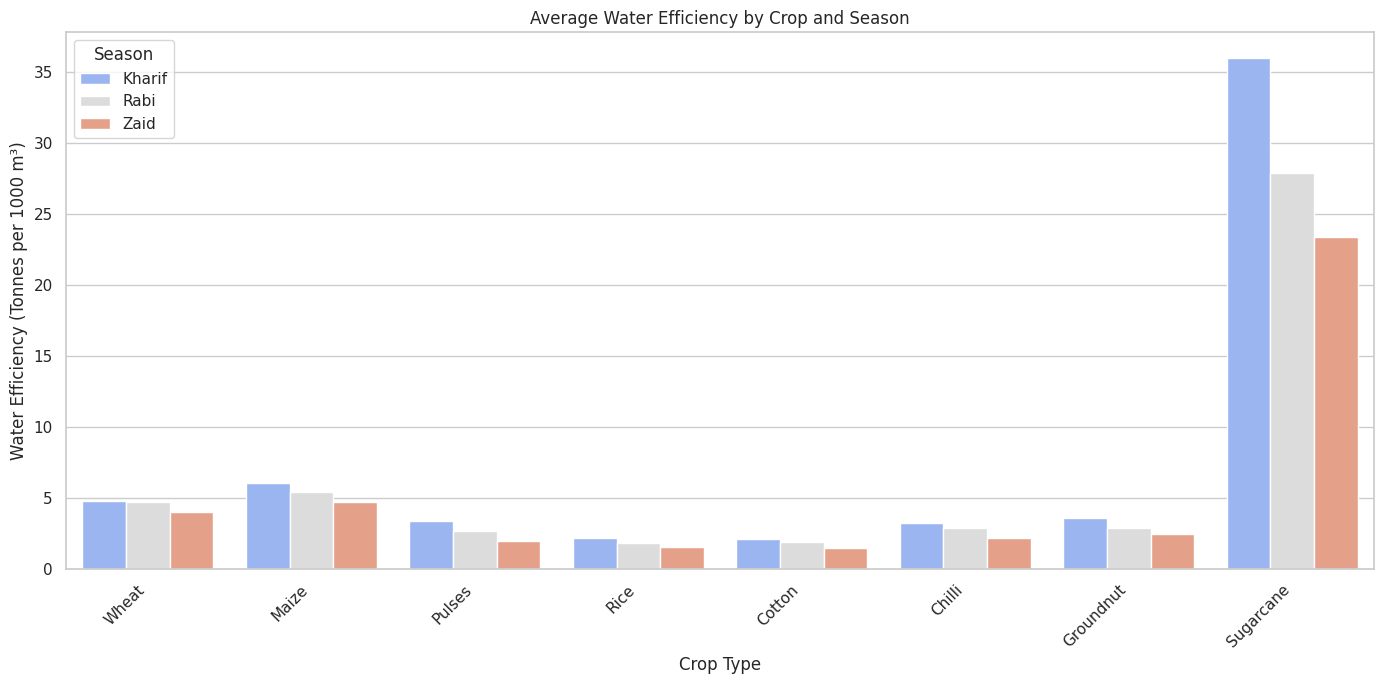

In [68]:
plt.figure(figsize=(14, 7))
sns.barplot(x='Crop', y='Water_Efficiency_t_per_1000m3', hue='Season', data=df, palette='coolwarm', errorbar=None)
plt.title('Average Water Efficiency by Crop and Season')
plt.xlabel('Crop Type')
plt.ylabel('Water Efficiency (Tonnes per 1000 m³)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Season')
plt.tight_layout()
plt.show()

**Interpretation:**
- Sugarcane, despite its high water usage, often exhibits higher water efficiency (tonnes of yield per 1000 cubic meters of water) compared to other crops, especially in Kharif and Rabi seasons. This suggests that its high yield compensates for the water input.
- Crops like Pulses, Groundnut, and Cotton generally show lower water efficiency across seasons, implying there might be opportunities for improving irrigation practices or selecting more water-efficient varieties for these crops.
- Seasonal variations in water efficiency for a given crop could be attributed to differing environmental conditions (e.g., rainfall availability) and specific seasonal farming practices.

# Answers to the Questions:


1.  **How does agricultural performance vary across seasons?**
    *   Agricultural performance varies significantly across seasons. The `Seasonal descriptive Summary` and `General seasonal summary` tables clearly show differences in mean and median values for `Yield_Tonnes_Ha`, `Profit_INR`, and `Water_Used_m3`.
    *   **Kharif** generally shows the highest average yield and profit. (Average_Yield: 5.63, Average_Profit: 178914.65).
    *   **Rabi** has moderate performance (Average_Yield: 5.04, Average_Profit: 87689.47).
    *   **Zaid** often exhibits the lowest average yield and, notably, a negative average profit (-24804.82), indicating it is the most challenging season economically.

2.  **What major seasonal patterns can be observed?**
    *   **Rainfall**: Kharif season receives significantly higher rainfall (mean 849.20mm) compared to Rabi (437.62mm) and Zaid (304.65mm).
    *   **Temperature**: Zaid is the warmest season (mean 31.04°C), followed by Kharif (28.45°C), and Rabi is the coolest (23.49°C).
    *   **Humidity**: Kharif is the most humid (mean 71.81%), while Zaid is the least (mean 52.01%).
    *   **Yield Distribution**: The box plot of `Yield_Tonnes_Ha` by `Season` shows Kharif and Rabi having generally higher median yields and a wider spread of high-yield outliers compared to Zaid.

3.  **Which characteristics change between seasons?**
    *   **Environmental Conditions**: Rainfall, Average Temperature, Humidity, and Sunlight Hours show distinct seasonal variations, as seen in the statistical summary grouped by season.
    *   **Crop Choices**: While all crops are planted in all seasons, their relative proportions and success rates (yield, profit) change. For example, Sugarcane yields are highest in Kharif.
    *   **Economic Outcomes**: `Profit_INR` is highly seasonal, with positive profits in Kharif and Rabi, and negative in Zaid, as shown in the `Average Profit by Season` bar plot.

4.  **What differences exist between agricultural activities in different seasons?**
    *   The primary differences revolve around the types of crops that thrive (e.g., Sugarcane and Chilli in Kharif and Rabi are highly profitable, while many crops struggle in Zaid) and resource management strategies (e.g., higher rainfall reliance in Kharif, increased irrigation needs in drier seasons).
    *   `Water_Used_m3` is highest in Zaid, followed by Kharif and Rabi, suggesting different irrigation demands based on rainfall patterns.

5.  **Are there noticeable variations in resource usage across seasons?**
    *   Yes, particularly in `Water_Used_m3`. Zaid season has the highest average water usage (6419.89 m³) despite being the driest, indicating a higher reliance on irrigation. Kharif and Rabi have slightly lower average water usage (6102.20 m³ and 5846.99 m³ respectively), as shown in the `Water Usage by Season` bar plot and `General seasonal summary`.

6.  **Are there relationships between seasonal environmental conditions and agricultural performance?**
    *   Yes. `Additional Analysis 1` (Yield vs. Rainfall, Temperature, Sunlight by Season) clearly illustrates these relationships. For example, high rainfall generally correlates with higher yields in Kharif, but extreme rainfall or drought in other seasons can be detrimental.
    *   The `Correlation Heatmap` shows various correlations between environmental factors and performance metrics across the entire dataset.

7.  **How do economic outcomes vary across seasons?**
    *   Economic outcomes vary dramatically. Kharif is the most profitable season, followed by Rabi. Zaid consistently shows negative average profits, indicating that, on average, farming in Zaid season results in losses. This is evident in the `Profit by Season` bar plot and the `Economic Performance (Profit) across Crops and Seasons` analysis.

8.  **Are some seasonal patterns consistent across different regions or categories?**
    *   The analysis focused on crop categories within seasons. `Additional Analysis 2` (`Average Profit by Crop and Season`) shows consistency in some crop performances (e.g., Sugarcane and Chilli generally profitable, Maize and Rice often unprofitable) across seasons. However, the analysis did not deeply explore consistency across `State` or `District` (regions) beyond initial descriptive statistics. Further grouping by `State` or `District` would be needed to answer this fully.

9.  **Are there unusual or unexpected seasonal patterns?**
    *   The significant negative average profits for several crops, especially in the Zaid season, could be considered an unexpected pattern, suggesting these crops may not be viable during that period without significant intervention.
    *   The high number of outliers in `Profit_INR`, `Production_Tonnes`, `Yield_Tonnes_Ha`, and `Water_Efficiency_t_per_1000m3` (identified in the IQR analysis) represent unusual individual farm performances that deviate significantly from the norm, potentially indicating exceptionally good or bad seasons for certain farms.

10. **What insights can be derived from the observed seasonal differences?**
    *   Crop selection is crucial for profitability, especially avoiding certain crops in the Zaid season.
    *   Water management strategies need to be adapted seasonally, with a higher focus on irrigation efficiency in drier periods.
    *   Environmental factors are strong determinants of yield, suggesting the importance of weather forecasting and adaptive farming practices.
    *   Sugarcane and Chilli are high-performing crops economically.

11. **What conclusions can reasonably be drawn from the available data?**
    *   Seasonal conditions profoundly impact agricultural performance, necessitating season-specific farming strategies.
    *   Kharif and Rabi are generally favorable seasons for agriculture, while Zaid presents considerable economic challenges.
    *   Profitability is highly crop- and season-dependent.
    *   There is a clear need for optimized water usage, especially in water-scarce seasons.

12. **How could the findings support better seasonal agricultural planning?**
    *   **Crop Selection**: Farmers can use the profit and yield data to choose the most suitable and profitable crops for each season, potentially avoiding high-risk crops in Zaid.
    *   **Resource Management**: Insights into water usage and efficiency can guide irrigation planning and promote water-saving technologies, particularly in Zaid.
    *   **Risk Mitigation**: Understanding the impact of environmental factors allows for better preparation against adverse weather conditions.
    *   **Policy Making**: The data can inform agricultural policies aimed at supporting farmers in challenging seasons or promoting specific crops and practices.